<a href="https://colab.research.google.com/github/asolergayoso/DS_5500_Ransomware_Detection/blob/tsnse_and_basic_classification/vis_and_class_poc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikeras

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GroupKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.ensemble import IsolationForest

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization

# Prepare Dataset

In [ ]:
def timedelta_to_ns(t):
    if type(t) == pd.Timedelta:
        return t.total_seconds() * 1e9 + t.nanoseconds
    else:
        return t.total_seconds() * 1e9

In [ ]:
df = pd.read_pickle("/content/final_dataset_new_features_all_logs_10s_window.pkl")

In [ ]:
df.head()

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_avg_gpa_jump,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,operation,operation_log_cnt,start_s,end_s
0,0 days 00:00:00,0 days 00:00:10,420300.8,78233.6,8.750598e+14,2.836417e+15,0.742203,0.049471,0.753775,9,...,5.529372e+09,1.951698e+10,1.0,0.959677,1.956886e+10,False,AESCrypt,1,0,10
1,0 days 00:00:01,0 days 00:00:11,420300.8,78233.6,8.750598e+14,2.836417e+15,0.742203,0.011468,0.595073,1,...,4.865936e+09,1.218004e+10,1.0,0.909091,1.937828e+10,False,AESCrypt,1,1,11
2,0 days 00:00:02,0 days 00:00:12,1121177.6,79052.8,4.981796e+14,2.843206e+15,0.740121,0.004692,NaN,0,...,2.166676e+09,7.452113e+09,1.0,0.333333,7.554102e+09,False,AESCrypt,1,2,12
3,0 days 00:00:03,0 days 00:00:13,1362073.6,6144.0,5.017219e+14,4.499802e+14,0.399652,0.008459,0.637976,0,...,2.758968e+09,7.482259e+09,1.0,1.000000,7.887104e+09,False,AESCrypt,1,3,13
4,0 days 00:00:04,0 days 00:00:14,1407027.2,4505.6,4.985177e+14,2.045721e+13,0.362840,0.008541,0.637976,0,...,2.758968e+09,7.482259e+09,1.0,1.000000,7.887104e+09,False,AESCrypt,1,4,14


## Remove Redundant Features

In [ ]:
non_target_features = ['start', 'end', 'operation_log_cnt']

# Obtained in EDA notebook
zero_var_features = ['num_MMIO_pages_mem_read_write', 'num_MMIO_pages_mem_exec', 'mem_exec_burst_clustering', 'mem_write_seq_addr_access_ratio', 'mem_read_write_seq_addr_access_ratio']

high_corr_features = ['mem_exec_seq_addr_access_ratio', 'num_MMIO_pages_mem_write', 'strg_read_event_rate', 'strg_write_event_rate', 'mem_read_burst_intensity', 'mem_read_event_rate', 'mem_write_burst_intensity',
 'mem_write_event_rate', 'mem_read_write_micro_burst_count', 'mem_read_write_event_rate', 'mem_exec_burst_intensity', 'mem_exec_event_rate', 'strg_read_lba_range', 'strg_write_lba_range',
 'mem_read_gpa_range', 'mem_write_gpa_range', 'mem_read_write_gpa_range', 'mem_exec_avg_gpa_jump', 'mem_exec_gpa_range', 'end_s']

In [ ]:
df = df.drop(columns= zero_var_features + high_corr_features)

## Null Imputation

In [ ]:
df["is_ransomware"] = df["is_ransomware"].astype(int)

window_delta = df.iloc[0]['end'] - df.iloc[0]['start']
step_delta = df[(df['operation']=='AESCrypt') & (df['operation_log_cnt']==1)]['start'].diff()[1]

time_to_high_entropy_cols = [col for col in df.columns if 'time_to_high_entropy' in col]
# Fill null values in time cols with (window_size + step)
df[time_to_high_entropy_cols] = df[time_to_high_entropy_cols].fillna(timedelta_to_ns(window_delta+step_delta))
df = df.fillna(0)


In [ ]:
df = df.drop(columns=non_target_features)

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
avg_ata_read,0
avg_ata_write,0
lba_read_var,0
lba_write_var,0
avg_storage_entropy,0
...,...
mem_exec_access_locality,0
mem_exec_frwrd_bckwrd_ratio,0
is_ransomware,0
operation,0


In [ ]:
features = df.drop(['is_ransomware', 'operation'], axis=1)

In [ ]:
features.head()

,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,...,mem_write_access_locality,mem_write_frwrd_bckwrd_ratio,mem_read_write_avg_gpa_jump,mem_read_write_max_gpa_jump,mem_read_write_access_locality,mem_read_write_frwrd_bckwrd_ratio,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,start_s
0,420300.8,78233.6,8.750598e+14,2.836417e+15,0.742203,0.049471,0.753775,9,0,0,...,0.075560,1.045977,4.827180e+09,1.282819e+10,1.0,1.083333e+00,1.951698e+10,1.0,0.959677,0
1,420300.8,78233.6,8.750598e+14,2.836417e+15,0.742203,0.011468,0.595073,1,0,0,...,0.021739,1.018036,3.837295e+09,1.188246e+10,1.0,1.333333e+00,1.218004e+10,1.0,0.909091,1
2,1121177.6,79052.8,4.981796e+14,2.843206e+15,0.740121,0.004692,0.000000,0,0,0,...,0.010748,1.038039,0.000000e+00,0.000000e+00,0.0,1.000000e+00,7.452113e+09,1.0,0.333333,2
3,1362073.6,6144.0,5.017219e+14,4.499802e+14,0.399652,0.008459,0.637976,0,0,0,...,0.018365,1.042804,5.839278e+09,1.146903e+10,1.0,2.000000e+10,7.482259e+09,1.0,1.000000,3
4,1407027.2,4505.6,4.985177e+14,2.045721e+13,0.362840,0.008541,0.637976,0,0,0,...,0.020258,1.048816,5.839278e+09,1.146903e+10,1.0,2.000000e+10,7.482259e+09,1.0,1.000000,4


## Scaling

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

df_scaled['is_ransomware'] = df['is_ransomware']
df_scaled['operation'] = df['operation']

display(df_scaled.head())

,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,...,mem_read_write_avg_gpa_jump,mem_read_write_max_gpa_jump,mem_read_write_access_locality,mem_read_write_frwrd_bckwrd_ratio,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,start_s,is_ransomware,operation
0,-0.878368,-0.502212,0.418015,1.446157,0.594071,2.924801,0.896507,2.043335,-0.145777,-0.12222,...,1.693510,1.535403,0.753044,-0.259010,6.791784,1.51701,-0.187157,-1.688739,0,AESCrypt
1,-0.878368,-0.502212,0.418015,1.446157,0.594071,0.122166,0.439580,-0.060666,-0.145777,-0.12222,...,1.256067,1.375755,0.753044,-0.259010,4.146235,1.51701,-0.187157,-1.671418,0,AESCrypt
2,-0.739546,-0.502171,-0.218869,1.453851,0.585746,-0.377586,-1.273726,-0.323667,-0.145777,-0.12222,...,-0.439683,-0.630097,-1.450105,-0.259010,2.441441,1.51701,-0.187157,-1.654098,0,AESCrypt
3,-0.691832,-0.505780,-0.212883,-1.258390,-0.775262,-0.099736,0.563105,-0.323667,-0.145777,-0.12222,...,2.140769,1.305966,0.753044,2.851109,2.452311,1.51701,-0.187157,-1.636777,0,AESCrypt
4,-0.682928,-0.505861,-0.218298,-1.745168,-0.922414,-0.093737,0.563105,-0.323667,-0.145777,-0.12222,...,2.140769,1.305966,0.753044,2.851109,2.452311,1.51701,-0.187157,-1.619456,0,AESCrypt


# **Visualizations**

The following are some visualizations of the dataset using different dimensionality reduction techniques

### TSNE

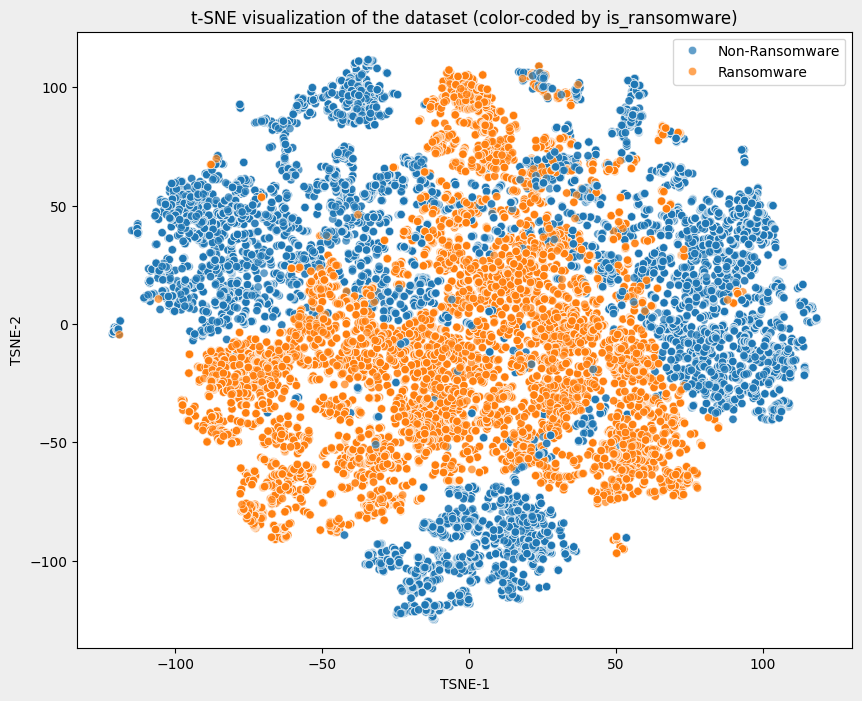

,TSNE-1,TSNE-2,is_ransomware,operation,ransomware_label
0,18.803898,105.417587,False,AESCrypt,Non-Ransomware
1,36.118710,60.929752,False,AESCrypt,Non-Ransomware
2,-112.706017,37.742043,False,AESCrypt,Non-Ransomware
3,-23.872330,46.056297,False,AESCrypt,Non-Ransomware
4,-24.011129,46.031673,False,AESCrypt,Non-Ransomware


In [ ]:
tsne_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(tsne_features)

df_tsne = pd.DataFrame(tsne_results, columns=['TSNE-1', 'TSNE-2'])
df_tsne['is_ransomware'] = df_scaled['is_ransomware'].astype(bool)
df_tsne['operation'] = df_scaled['operation']

hue_labels = {True: 'Ransomware', False: 'Non-Ransomware'}
df_tsne['ransomware_label'] = df_tsne['is_ransomware'].map(hue_labels)


plt.figure(figsize=(10, 8))
plt.gcf().set_facecolor("#eeeeeeff")
sns.scatterplot(
    x="TSNE-1", y="TSNE-2",
    hue="ransomware_label",
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE visualization of the dataset (color-coded by is_ransomware)')
plt.legend(title=None)
plt.show()

display(df_tsne.head())

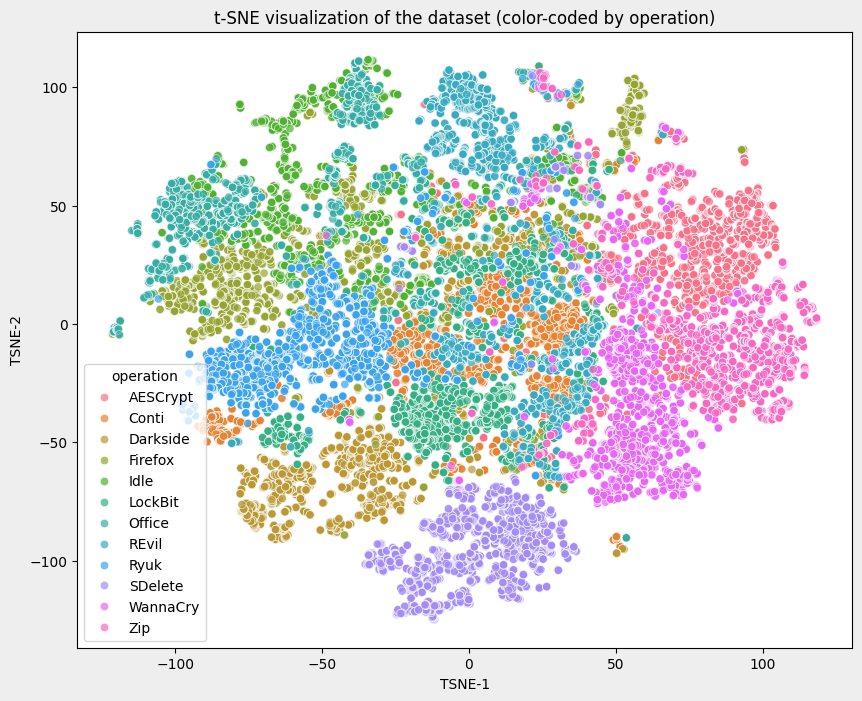

In [ ]:
plt.figure(figsize=(10, 8))
plt.gcf().set_facecolor("#eeeeeeff")
sns.scatterplot(
    x="TSNE-1", y="TSNE-2",
    hue="operation",
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE visualization of the dataset (color-coded by operation)')
plt.show()


## PCA with 2 components

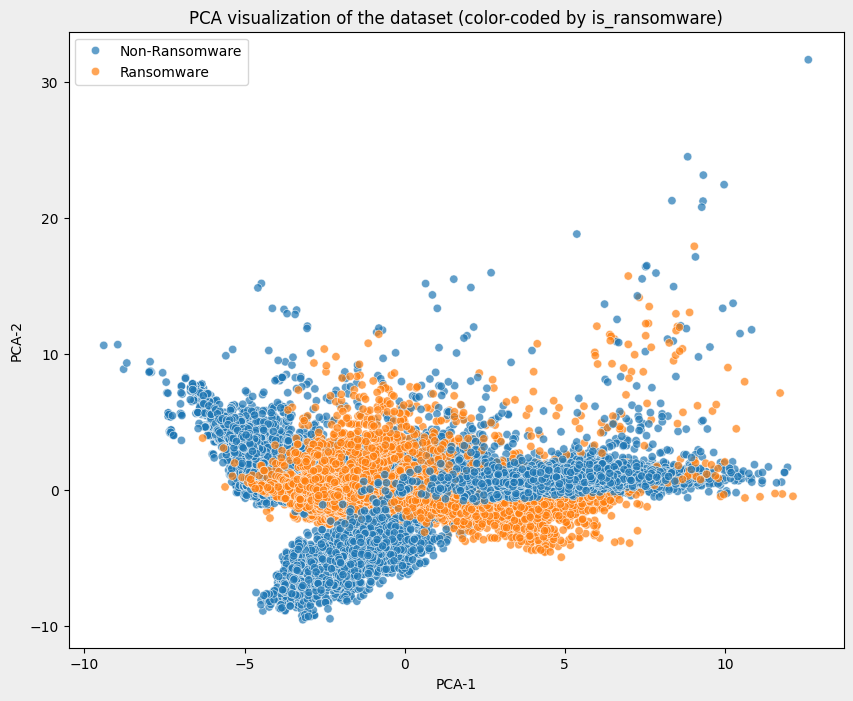

,PCA-1,PCA-2,is_ransomware,ransomware_label
0,8.400249,14.930182,False,Non-Ransomware
1,1.403390,4.391324,False,Non-Ransomware
2,-2.642075,1.704337,False,Non-Ransomware
3,-1.641335,3.444471,False,Non-Ransomware
4,-1.308993,3.414021,False,Non-Ransomware


In [ ]:
pca_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(pca_features)

df_pca = pd.DataFrame(pca_results, columns=['PCA-1', 'PCA-2'])
df_pca['is_ransomware'] = df_scaled['is_ransomware'].astype(bool)

hue_labels = {True: 'Ransomware', False: 'Non-Ransomware'}
df_pca['ransomware_label'] = df_tsne['is_ransomware'].map(hue_labels)

plt.figure(figsize=(10, 8))
plt.gcf().set_facecolor("#eeeeeeff")
sns.scatterplot(
    x="PCA-1", y="PCA-2",
    hue="ransomware_label",
    data=df_pca,
    legend="full",
    alpha=0.7
)
plt.title('PCA visualization of the dataset (color-coded by is_ransomware)')
plt.legend(title=None)
plt.show()

display(df_pca.head())

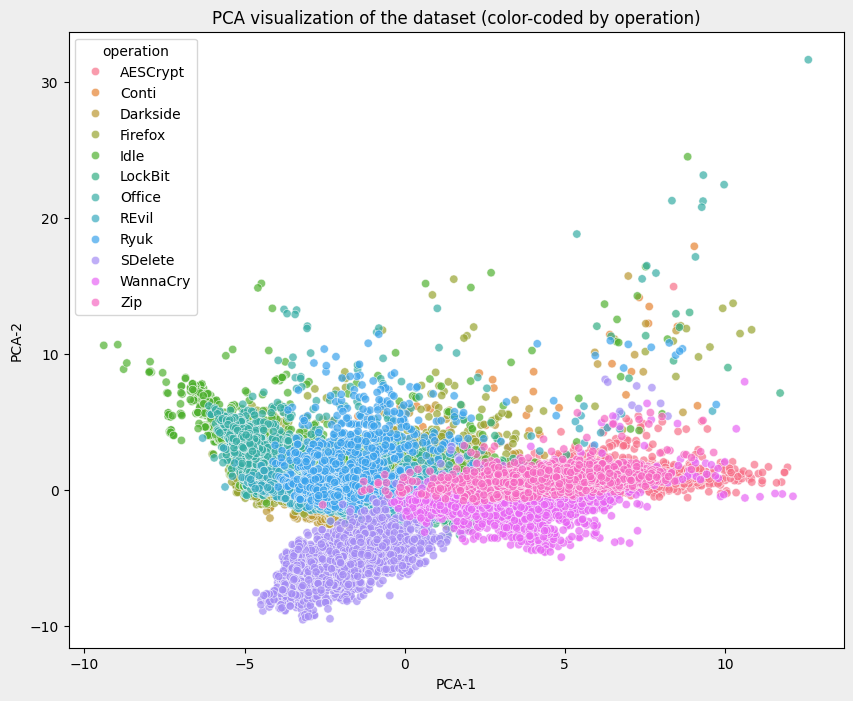

In [ ]:
df_pca_operation = pd.DataFrame(pca_results, columns=['PCA-1', 'PCA-2'])
df_pca_operation['operation'] = df_scaled['operation']

plt.figure(figsize=(10, 8))
plt.gcf().set_facecolor("#eeeeeeff")
sns.scatterplot(
    x="PCA-1", y="PCA-2",
    hue="operation",
    data=df_pca_operation,
    legend="full",
    alpha=0.7
)
plt.title('PCA visualization of the dataset (color-coded by operation)')
plt.show()

## PCA with 3 components

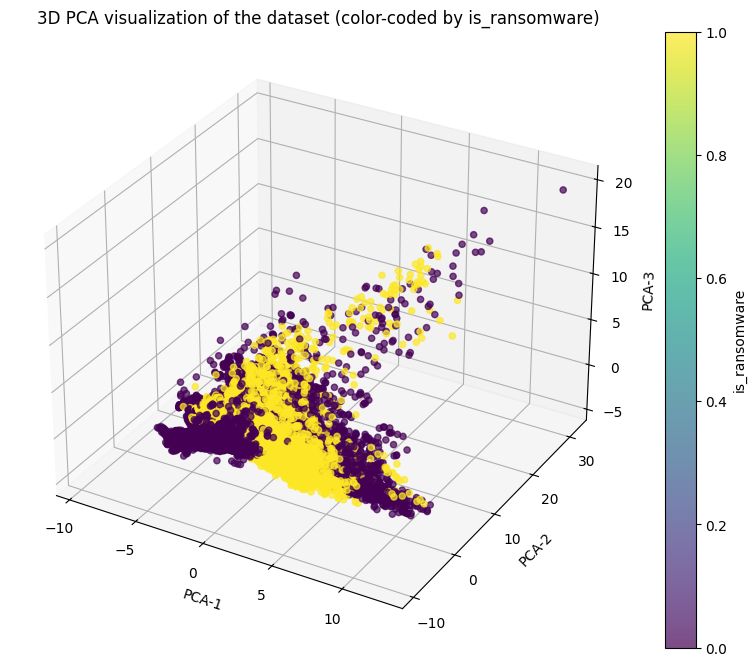

,PCA-1,PCA-2,PCA-3,is_ransomware
0,8.400249,14.930182,15.072011,0
1,1.403390,4.391324,6.316081,0
2,-2.642075,1.704337,2.521054,0
3,-1.641335,3.444471,4.372510,0
4,-1.308993,3.414021,4.352912,0


In [ ]:
pca_features = df_scaled.drop(['is_ransomware', 'operation'], axis=1)

pca = PCA(n_components=3, random_state=42)
pca_results = pca.fit_transform(pca_features)

df_pca_3d = pd.DataFrame(pca_results, columns=['PCA-1', 'PCA-2', 'PCA-3'])
df_pca_3d['is_ransomware'] = df_scaled['is_ransomware']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_pca_3d['PCA-1'],
    df_pca_3d['PCA-2'],
    df_pca_3d['PCA-3'],
    c=df_pca_3d['is_ransomware'],
    cmap='viridis',
    alpha=0.7
)

ax.set_xlabel('PCA-1')
ax.set_ylabel('PCA-2')
ax.set_zlabel('PCA-3')
plt.title('3D PCA visualization of the dataset (color-coded by is_ransomware)')
plt.colorbar(scatter, label='is_ransomware')
plt.show()

display(df_pca_3d.head())

# **Binary Classification**

Different models will be trained with the scaled data to get a basic sense of accuracy

In [ ]:
X = df_scaled.drop(columns = ['is_ransomware', 'operation'])
y = df_scaled["is_ransomware"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def evaluate(model, X_train, y_train, X_test, y_test):
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  print(classification_report(y_test, y_pred, target_names=['Not Ransomware', 'Ransomware']))
  cm = confusion_matrix(y_test, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ransomware', 'Ransomware'])
  disp.plot(cmap=plt.cm.Blues)
  plt.title('Confusion Matrix')
  plt.show()

### Decision Tree

                precision    recall  f1-score   support

Not Ransomware       0.98      0.99      0.98      2215
    Ransomware       0.99      0.98      0.99      2449

      accuracy                           0.99      4664
     macro avg       0.99      0.99      0.99      4664
  weighted avg       0.99      0.99      0.99      4664



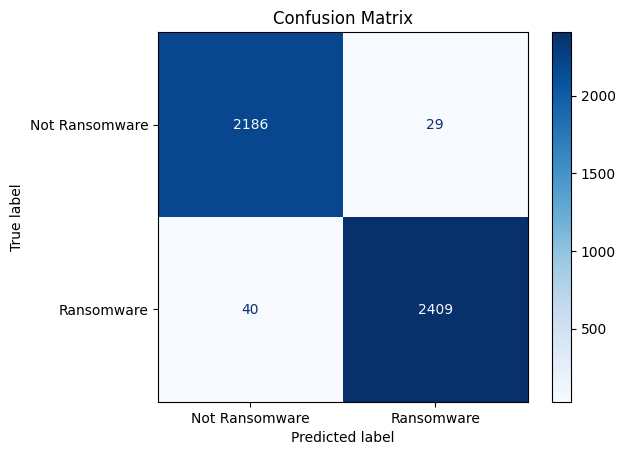

In [ ]:
evaluate(DecisionTreeClassifier(random_state=42), X_train, y_train, X_test, y_test)

### Support Vector Machine

                precision    recall  f1-score   support

Not Ransomware       0.99      0.99      0.99      2215
    Ransomware       0.99      0.99      0.99      2449

      accuracy                           0.99      4664
     macro avg       0.99      0.99      0.99      4664
  weighted avg       0.99      0.99      0.99      4664



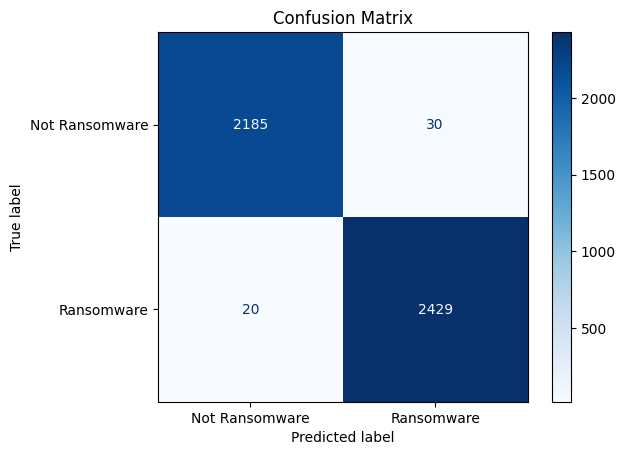

In [ ]:
evaluate(SVC(random_state=42), X_train, y_train, X_test, y_test)

### Neural Network

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


                precision    recall  f1-score   support

Not Ransomware       1.00      1.00      1.00      2215
    Ransomware       1.00      1.00      1.00      2449

      accuracy                           1.00      4664
     macro avg       1.00      1.00      1.00      4664
  weighted avg       1.00      1.00      1.00      4664



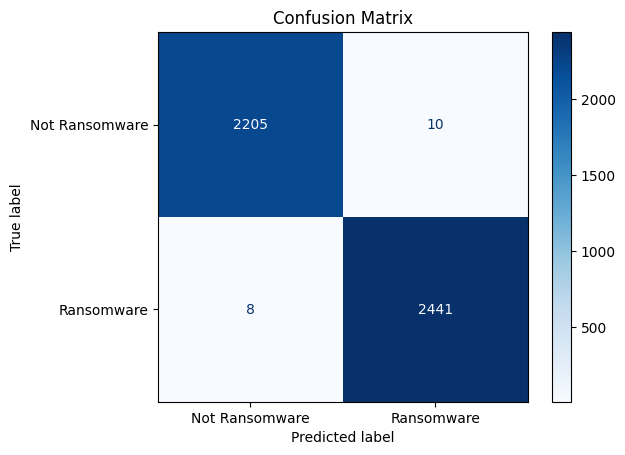

In [ ]:
print(classification_report(y_test, y_pred, target_names=['Not Ransomware', 'Ransomware']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ransomware', 'Ransomware'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

## Random Group CV

In [ ]:
def group_cross_validate_model(model, X, y, groups, model_name="Model"):
    """
    Runs GroupKFold CV, where 'operation' indicates malware subclass.
    This simulates testing on unseen ransomware behavior groups.
    """
    scoring = {
        "acc": "accuracy",
        "prec": "precision",
        "rec": "recall",
        "f1": "f1",
    }

    unique_groups = pd.Series(groups).nunique()
    if unique_groups < 5:
        print(f"[Warning] Only {unique_groups} unique 'operation' groups available. "
              "GroupKFold requires at least 5 for 5-fold CV.")
        return

    gkf = GroupKFold(n_splits=5)
    results = cross_validate(
        model, X, y,
        cv=gkf.split(X, y, groups=groups),
        scoring=scoring,
        return_train_score=False
    )

    print(f"\n===== {model_name}: GroupKFold CV by 'operation' =====")
    for metric, scores in results.items():
        if metric.startswith("test_"):
            m = metric.replace("test_", "")
            print(f"{m}: mean={np.mean(scores):.4f}, std={np.std(scores):.4f}")

In [ ]:
groups = df_scaled['operation']

In [ ]:
# Decision Tree: stratified CV + GroupKFold by 'operation'
group_cross_validate_model(DecisionTreeClassifier(random_state=42),
                     X, y, groups=groups, model_name="Decision Tree")


===== Decision Tree: GroupKFold CV by 'operation' =====
acc: mean=0.6175, std=0.1797
prec: mean=0.6076, std=0.3852
rec: mean=0.4231, std=0.2707
f1: mean=0.4763, std=0.2933


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# SVM: stratified CV + GroupKFold by 'operation'
group_cross_validate_model(SVC(random_state=42),
                     X, y, groups=groups, model_name="SVM")


===== SVM: GroupKFold CV by 'operation' =====
acc: mean=0.6259, std=0.1028
prec: mean=0.6663, std=0.3672
rec: mean=0.5332, std=0.3147
f1: mean=0.5610, std=0.2849


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def build_nn_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def group_kfold_nn_cv(X, y, groups, epochs=10, batch_size=32):
    gkf = GroupKFold(n_splits=5)
    metrics = {
        "acc": [],
        "prec": [],
        "rec": [],
        "f1": []
    }

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        print(f"\n===== Fold {fold+1} (GroupKFold by 'operation') =====")

        X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

        model = build_nn_model(input_dim=X.shape[1])
        model.fit(X_train_fold, y_train_fold, epochs=epochs, batch_size=batch_size, verbose=0)

        y_pred_prob = model.predict(X_test_fold)
        y_pred = (y_pred_prob > 0.5).astype(int)

        acc = accuracy_score(y_test_fold, y_pred)
        prec = precision_score(y_test_fold, y_pred, zero_division=0)
        rec = recall_score(y_test_fold, y_pred, zero_division=0)
        f1 = f1_score(y_test_fold, y_pred, zero_division=0)

        print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

        metrics["acc"].append(acc)
        metrics["prec"].append(prec)
        metrics["rec"].append(rec)
        metrics["f1"].append(f1)

    print("\n===== Neural Network GroupKFold CV Results =====")
    for metric, values in metrics.items():
        print(f"{metric.upper()}: mean={np.mean(values):.4f}, std={np.std(values):.4f}")

In [ ]:
group_kfold_nn_cv(X, y, groups=groups)


===== Fold 1 (GroupKFold by 'operation') =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.4639, Precision: 1.0000, Recall: 0.4639, F1: 0.6338

===== Fold 2 (GroupKFold by 'operation') =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.6990, Precision: 0.5431, Recall: 0.9764, F1: 0.6980

===== Fold 3 (GroupKFold by 'operation') =====


...

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.6555, Precision: 0.6712, Recall: 0.6550, F1: 0.6630

===== Fold 4 (GroupKFold by 'operation') =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy: 0.5974, Precision: 1.0000, Recall: 0.5974, F1: 0.7480

===== Fold 5 (GroupKFold by 'operation') =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.6198, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

===== Neural Network GroupKFold CV Results =====
ACC: mean=0.6071, std=0.0794
PREC: mean=0.6429, std=0.3685
REC: mean=0.5385, std=0.3176
F1: mean=0.5486, std=0.2769


## Classification using unseen ransomware & benign pair as test set

In [ ]:
df_scaled.head()

,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,num_4KB_pages_mem_write,num_4KB_pages_mem_read_write,...,mem_read_write_avg_gpa_jump,mem_read_write_max_gpa_jump,mem_read_write_access_locality,mem_read_write_frwrd_bckwrd_ratio,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,start_s,is_ransomware,operation
0,-0.878368,-0.502212,0.418015,1.446157,0.594071,2.924801,0.896507,2.043335,-0.145777,-0.12222,...,1.693510,1.535403,0.753044,-0.259010,6.791784,1.51701,-0.187157,-1.688739,0,AESCrypt
1,-0.878368,-0.502212,0.418015,1.446157,0.594071,0.122166,0.439580,-0.060666,-0.145777,-0.12222,...,1.256067,1.375755,0.753044,-0.259010,4.146235,1.51701,-0.187157,-1.671418,0,AESCrypt
2,-0.739546,-0.502171,-0.218869,1.453851,0.585746,-0.377586,-1.273726,-0.323667,-0.145777,-0.12222,...,-0.439683,-0.630097,-1.450105,-0.259010,2.441441,1.51701,-0.187157,-1.654098,0,AESCrypt
3,-0.691832,-0.505780,-0.212883,-1.258390,-0.775262,-0.099736,0.563105,-0.323667,-0.145777,-0.12222,...,2.140769,1.305966,0.753044,2.851109,2.452311,1.51701,-0.187157,-1.636777,0,AESCrypt
4,-0.682928,-0.505861,-0.218298,-1.745168,-0.922414,-0.093737,0.563105,-0.323667,-0.145777,-0.12222,...,2.140769,1.305966,0.753044,2.851109,2.452311,1.51701,-0.187157,-1.619456,0,AESCrypt


In [ ]:
def pair_cross_validation(de_reduced, model, nn=False):
  ransomware_operations = de_reduced[de_reduced['is_ransomware'] == 1]['operation'].unique()
  non_ransomware_operations = de_reduced[de_reduced['is_ransomware'] == 0]['operation'].unique()

  cv_folds = []
  for r_op in ransomware_operations:
      for non_r_op in non_ransomware_operations:
          test_mask = de_reduced['operation'].isin([r_op, non_r_op])
          train_mask = ~test_mask
          cv_folds.append((train_mask, test_mask))

  print(f"Created {len(cv_folds)} cross-validation folds.")

  evaluation_results = []
  all_fpr = []
  all_tpr = []
  all_auc = []

  initial_weights = None
  if nn:
      initial_weights = model.get_weights()

  for train_mask, test_mask in tqdm(cv_folds, desc="Processing folds"):
      X_train = de_reduced[train_mask].drop(['is_ransomware', 'operation'], axis=1)
      y_train = de_reduced[train_mask]['is_ransomware']
      X_test = de_reduced[test_mask].drop(['is_ransomware', 'operation'], axis=1)
      y_test = de_reduced[test_mask]['is_ransomware']

      if nn:
        model.set_weights(initial_weights)
        model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

      if len(y_test.unique()) < 2:
          print(f"Skipping fold for pair {de_reduced[test_mask]['operation'].unique()} as it does not contain both classes.")
          continue

      model.fit(X_train, y_train)

      y_pred = model.predict(X_test)
      if nn:
        y_pred = (y_pred > 0.5).astype(int)

      try:
          y_pred_proba = model.predict_proba(X_test)[:, 1]
      except AttributeError:
          y_pred_proba = None

      report = classification_report(y_test, y_pred, output_dict=True)
      cm = confusion_matrix(y_test, y_pred)
      if y_pred_proba is not None and len(np.unique(y_test)) > 1:
          auc = roc_auc_score(y_test, y_pred_proba)
          fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
          all_fpr.append(fpr)
          all_tpr.append(tpr)
          all_auc.append(auc)
      else:
          auc = np.nan
          fpr, tpr = None, None


      current_pair = tuple(de_reduced[test_mask]['operation'].unique())

      evaluation_results.append({
          'operation_pair': current_pair,
          'classification_report': report,
          'confusion_matrix': cm.tolist(), # Convert numpy array to list for easier storage
          'auc': auc,
      })

  return evaluation_results, all_fpr, all_tpr, all_auc


def plot_fold_matrix(results, de_reduced):
  f1_scores_ransomware_non_ransomware = {}
  precision_scores = []
  recall_scores = []
  f1_scores = []
  auc_scores = []


  ransomware_operations = de_reduced[de_reduced['is_ransomware'] == 1]['operation'].unique()
  non_ransomware_operations = de_reduced[de_reduced['is_ransomware'] == 0]['operation'].unique()


  for r_op in ransomware_operations:
      f1_scores_ransomware_non_ransomware[r_op] = {}
      for non_r_op in non_ransomware_operations:
          f1_scores_ransomware_non_ransomware[r_op][non_r_op] = np.nan

  for result in results:
      pair = result['operation_pair']
      if len(pair) == 2:
          op1, op2 = pair

          if '1' in result['classification_report']:
              precision_scores.append(result['classification_report']['1']['precision'])
              recall_scores.append(result['classification_report']['1']['recall'])
              f1_scores.append(result['classification_report']['1']['f1-score'])
          if not np.isnan(result['auc']):
              auc_scores.append(result['auc'])


          if op1 in ransomware_operations and op2 in non_ransomware_operations:
              if '1' in result['classification_report']:
                  f1_score_ransomware = result['classification_report']['1']['f1-score']
                  f1_scores_ransomware_non_ransomware[op1][op2] = f1_score_ransomware
          elif op2 in ransomware_operations and op1 in non_ransomware_operations:
              if '1' in result['classification_report']:
                  f1_score_ransomware = result['classification_report']['1']['f1-score']
                  f1_scores_ransomware_non_ransomware[op2][op1] = f1_score_ransomware


  f1_df_filtered = pd.DataFrame(f1_scores_ransomware_non_ransomware)

  plt.figure(figsize=(12, 10))
  # plt.gcf().set_facecolor("#eeeeeeff")
  sns.heatmap(f1_df_filtered, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
  plt.title('F1-Score for Ransomware Class by Unseen Ransomware vs. Non-Ransomware Pair')
  plt.xlabel('Unseen Ransomware Operation')
  plt.ylabel('Unseen Non-Ransomware Operation')
  plt.show()

  print("\n===== Average Metrics Across Folds =====")
  print(f"Average Precision: {np.mean(precision_scores):.4f}")
  print(f"Average Recall: {np.mean(recall_scores):.4f}")
  print(f"Average F1-Score: {np.mean(f1_scores):.4f}")


In [ ]:
p_cv_dec_tree_res = pair_cross_validation(df_scaled, DecisionTreeClassifier(random_state=42))

Created 36 cross-validation folds.


Processing folds: 100%|██████████| 36/36 [01:16<00:00,  2.14s/it]


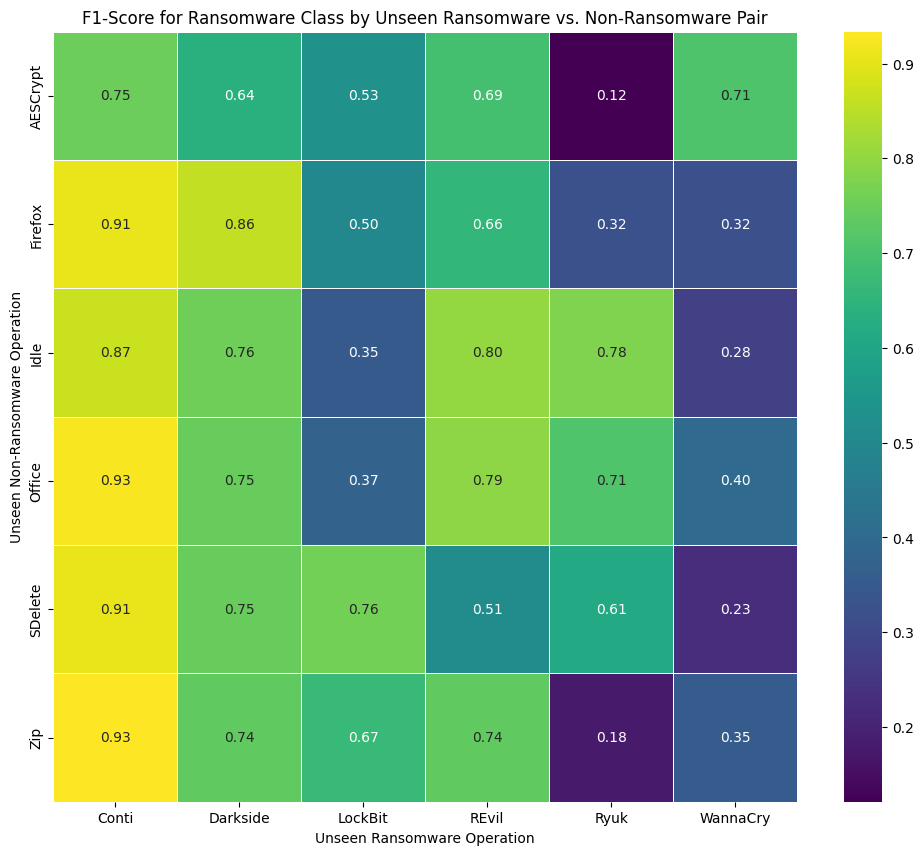


===== Average Metrics Across Folds =====
Average Precision: 0.6757
Average Recall: 0.5987
Average F1-Score: 0.6152


In [ ]:
plot_fold_matrix(p_cv_dec_tree_res[0], df_scaled)

In [ ]:
p_cv_svc_res = pair_cross_validation(df_scaled, SVC(random_state=42))

Created 36 cross-validation folds.


Processing folds: 100%|██████████| 36/36 [02:34<00:00,  4.31s/it]


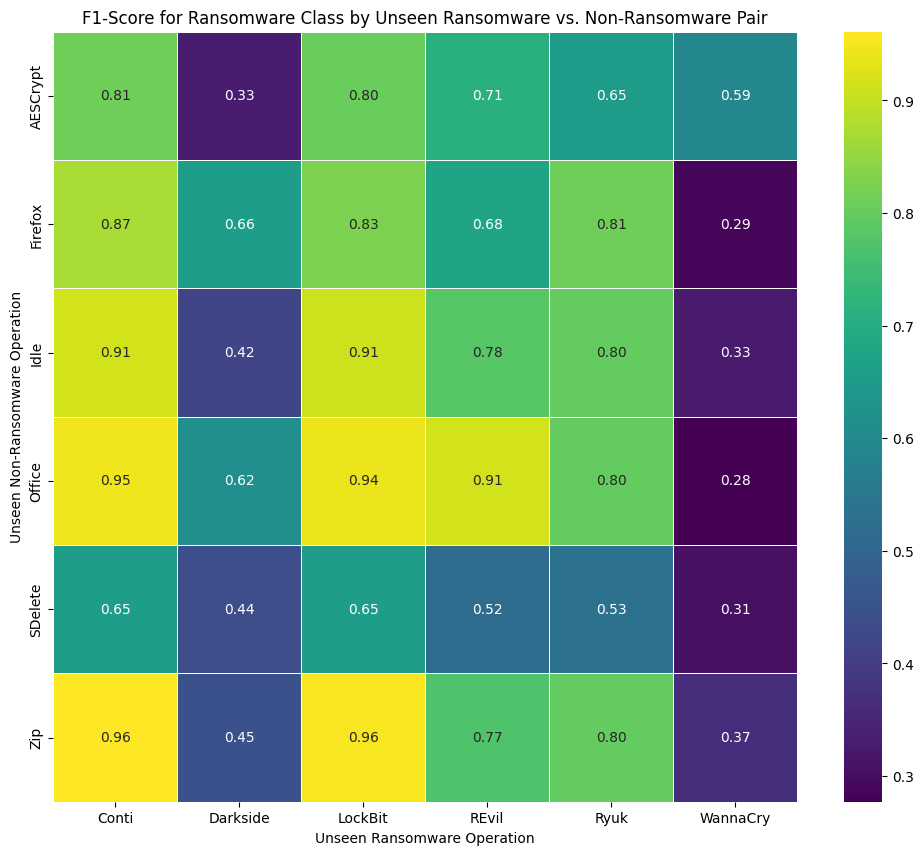


===== Average Metrics Across Folds =====
Average Precision: 0.7254
Average Recall: 0.6746
Average F1-Score: 0.6684


In [ ]:
plot_fold_matrix(p_cv_svc_res[0], df_scaled)

In [ ]:
p_cv_iso_frst_res = pair_cross_validation(df_scaled, IsolationForest(random_state=42))

Created 36 cross-validation folds.


Processing folds:   0%|          | 0/36 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/

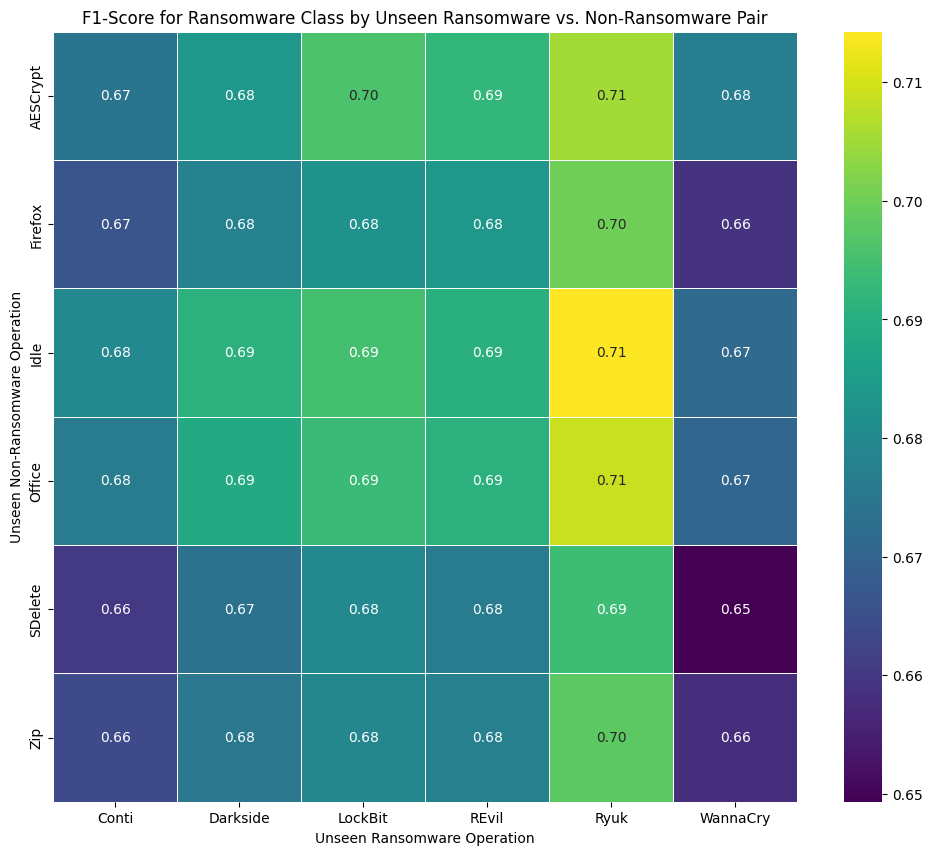


===== Average Metrics Across Folds =====
Average Precision: 0.5203
Average Recall: 0.9901
Average F1-Score: 0.6820


In [ ]:
plot_fold_matrix(p_cv_iso_frst_res[0], df_scaled)

Created 36 cross-validation folds.


Processing folds:   0%|          | 0/36 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/

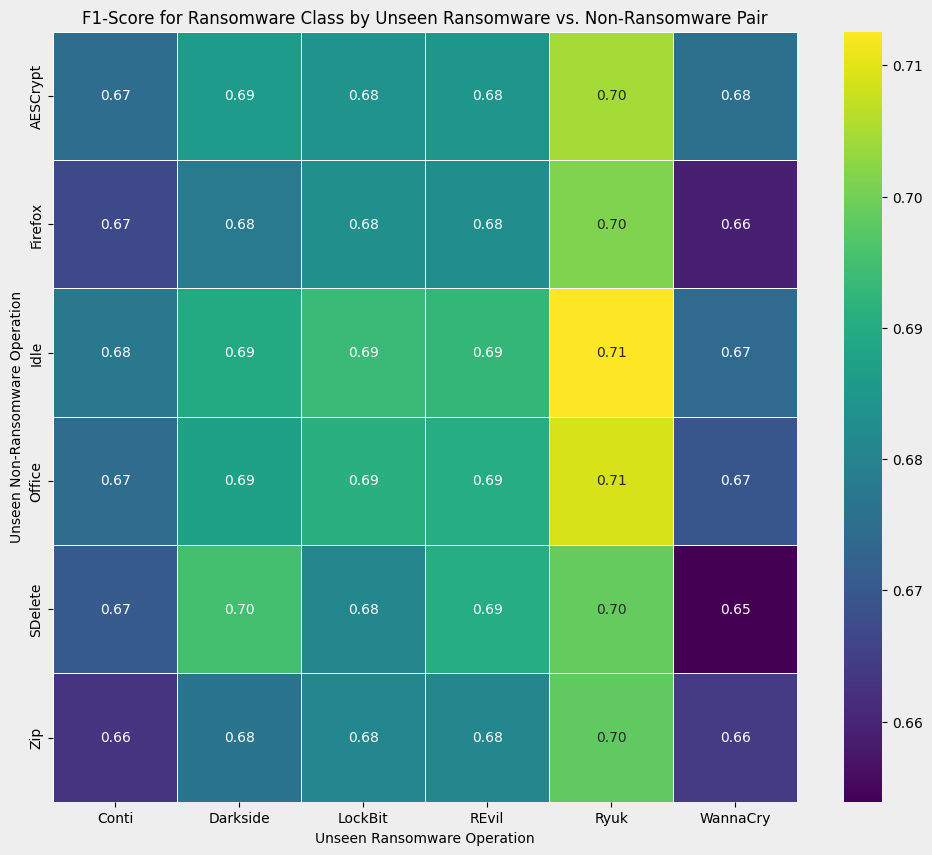


===== Average Metrics Across Folds =====
Average Precision: 0.5215
Average Recall: 0.9908
Average F1-Score: 0.6832


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


TypeError: 'numpy.float64' object does not support item assignment

<Figure size 1000x800 with 0 Axes>

In [ ]:
cross_validation(IsolationForest(random_state=42))

In [ ]:
num_features = df_scaled.drop(columns=['is_ransomware', 'operation', 'operation_log_cnt'], errors='ignore').shape[1]

model = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

p_cv_ffn_res = pair_cross_validation(df_scaled, model, nn = True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Created 36 cross-validation folds.


Processing folds:   0%|          | 0/36 [00:00<?, ?it/s]

611/611 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8830 - loss: 0.2778
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


Processing folds:   3%|▎         | 1/36 [00:12<07:27, 12.79s/it]

...

Processing folds:  94%|█████████▍| 34/36 [02:36<00:08,  4.08s/it]

610/610 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8959 - loss: 0.2522
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Processing folds:  97%|█████████▋| 35/36 [02:40<00:04,  4.00s/it]

611/611 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9039 - loss: 0.2503
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Processing folds: 100%|██████████| 36/36 [02:46<00:00,  4.62s/it]


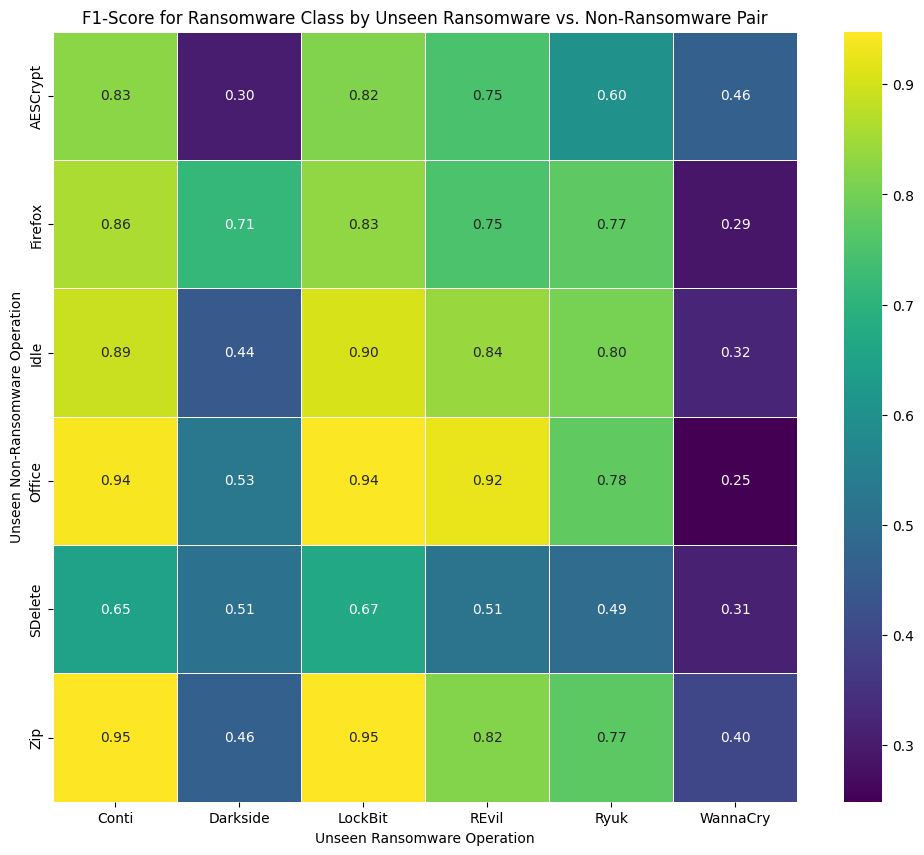


===== Average Metrics Across Folds =====
Average Precision: 0.7039
Average Recall: 0.6911
Average F1-Score: 0.6673


In [ ]:
plot_fold_matrix(p_cv_ffn_res[0], df_scaled)

Created 36 cross-validation folds.


Processing folds:   0%|          | 0/36 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


611/611 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9159 - loss: 0.2487
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Processing folds:   3%|▎         | 1/36 [00:07<04:15,  7.31s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


610/610 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9106 - loss: 0.2587
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


...

Processing folds:  94%|█████████▍| 34/36 [04:02<00:14,  7.38s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


610/610 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9145 - loss: 0.2502
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Processing folds:  97%|█████████▋| 35/36 [04:09<00:07,  7.22s/it]/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


611/611 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9148 - loss: 0.2583
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Processing folds: 100%|██████████| 36/36 [04:16<00:00,  7.13s/it]


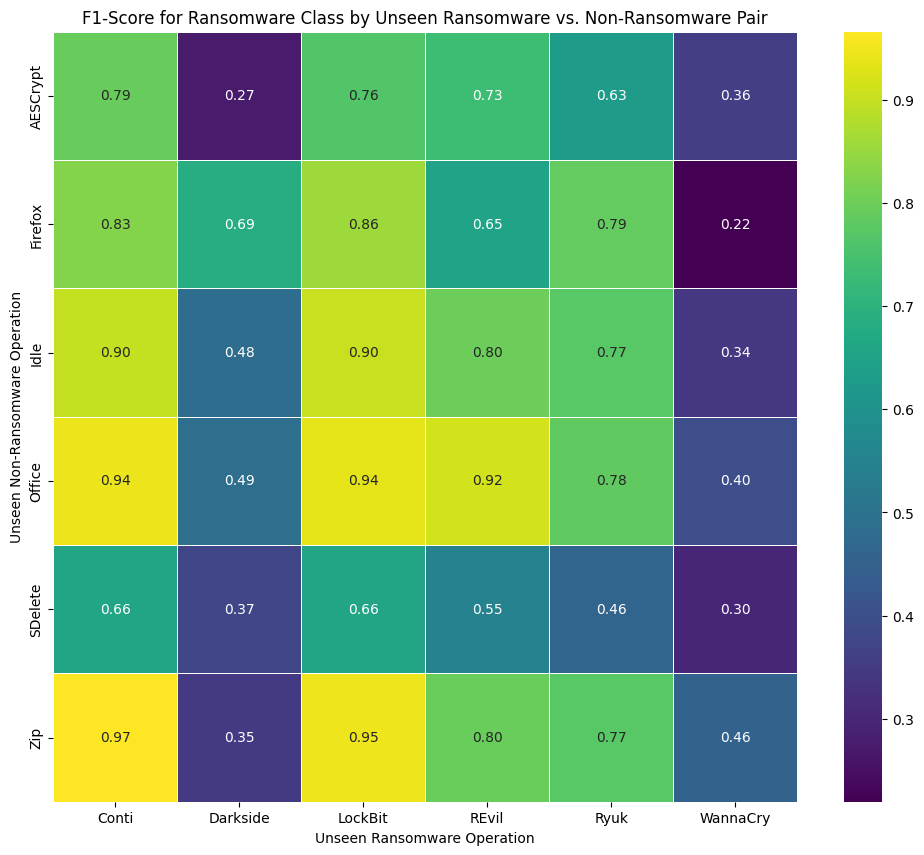


===== Average Metrics Across Folds =====
Average Precision: 0.6971
Average Recall: 0.6722
Average F1-Score: 0.6533


In [ ]:
def _plot_fold_matrix(results, de_reduced):
  f1_scores_ransomware_non_ransomware = {}
  precision_scores = []
  recall_scores = []
  f1_scores = []
  auc_scores = []


  ransomware_operations = de_reduced[de_reduced['is_ransomware'] == 1]['operation'].unique()
  non_ransomware_operations = de_reduced[de_reduced['is_ransomware'] == 0]['operation'].unique()


  for r_op in ransomware_operations:
      f1_scores_ransomware_non_ransomware[r_op] = {}
      for non_r_op in non_ransomware_operations:
          f1_scores_ransomware_non_ransomware[r_op][non_r_op] = np.nan

  for result in results:
      pair = result['operation_pair']
      if len(pair) == 2:
          op1, op2 = pair

          if '1' in result['classification_report']:
              precision_scores.append(result['classification_report']['1']['precision'])
              recall_scores.append(result['classification_report']['1']['recall'])
              f1_scores.append(result['classification_report']['1']['f1-score'])
          if not np.isnan(result['auc']):
              auc_scores.append(result['auc'])


          if op1 in ransomware_operations and op2 in non_ransomware_operations:
              if '1' in result['classification_report']:
                  f1_score_ransomware = result['classification_report']['1']['f1-score']
                  f1_scores_ransomware_non_ransomware[op1][op2] = f1_score_ransomware
          elif op2 in ransomware_operations and op1 in non_ransomware_operations:
              if '1' in result['classification_report']:
                  f1_score_ransomware = result['classification_report']['1']['f1-score']
                  f1_scores_ransomware_non_ransomware[op2][op1] = f1_score_ransomware


  f1_df_filtered = pd.DataFrame(f1_scores_ransomware_non_ransomware)

  plt.figure(figsize=(12, 10))
  sns.heatmap(f1_df_filtered, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
  plt.title('F1-Score for Ransomware Class by Unseen Ransomware vs. Non-Ransomware Pair')
  plt.xlabel('Unseen Ransomware Operation')
  plt.ylabel('Unseen Non-Ransomware Operation')
  plt.show()

  print("\n===== Average Metrics Across Folds =====")
  print(f"Average Precision: {np.mean(precision_scores):.4f}")
  print(f"Average Recall: {np.mean(recall_scores):.4f}")
  print(f"Average F1-Score: {np.mean(f1_scores):.4f}")
  # if auc_scores:
  #     print(f"Average AUC: {np.mean(auc_scores):.4f}")
  # else:
  #     print("AUC could not be calculated for any fold (likely due to only one class in test sets).")


ransomware_operations = df_scaled[df_scaled['is_ransomware'] == 1]['operation'].unique()
non_ransomware_operations = df_scaled[df_scaled['is_ransomware'] == 0]['operation'].unique()

cv_folds = []
for r_op in ransomware_operations:
    for non_r_op in non_ransomware_operations:
        test_mask = df_scaled['operation'].isin([r_op, non_r_op])
        train_mask = ~test_mask
        cv_folds.append((train_mask, test_mask))

print(f"Created {len(cv_folds)} cross-validation folds.")

evaluation_results = []
all_fpr = []
all_tpr = []
all_auc = []


for train_mask, test_mask in tqdm(cv_folds, desc="Processing folds"):
    X_train = df_scaled[train_mask].drop(['is_ransomware', 'operation'], axis=1)
    y_train = df_scaled[train_mask]['is_ransomware']
    X_test = df_scaled[test_mask].drop(['is_ransomware', 'operation'], axis=1)
    y_test = df_scaled[test_mask]['is_ransomware']

    if len(y_test.unique()) < 2:
        print(f"Skipping fold for pair {df_scaled[test_mask]['operation'].unique()} as it does not contain both classes.")
        continue

    X_train = np.reshape(X_train.values, (X_train.shape[0], 1, X_train.shape[1]))
    X_test = np.reshape(X_test.values, (X_test.shape[0], 1, X_test.shape[1]))

    model = Sequential([
      LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
      BatchNormalization(),
      LSTM(32),
      Dropout(0.2),
      Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy'])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred = (y_pred > 0.5).astype(int)

    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    except AttributeError:
        y_pred_proba = None

    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    if y_pred_proba is not None and len(np.unique(y_test)) > 1:
        auc = roc_auc_score(y_test, y_pred_proba)
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        all_fpr.append(fpr)
        all_tpr.append(tpr)
        all_auc.append(auc)
    else:
        auc = np.nan
        fpr, tpr = None, None


    current_pair = tuple(df_scaled[test_mask]['operation'].unique())

    evaluation_results.append({
        'operation_pair': current_pair,
        'classification_report': report,
        'confusion_matrix': cm.tolist(),
        'auc': auc,
    })
_plot_fold_matrix(evaluation_results, df_scaled)
# _plot_average_roc_curve(all_fpr, all_tpr, all_auc)



def _plot_average_roc_curve(all_fpr, all_tpr, all_auc):
    plt.figure(figsize=(10, 8))
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    for i in range(len(all_fpr)):
        tprs.append(np.interp(mean_fpr, all_fpr[i], all_tpr[i]))
        tprs[-1][0] = 0.0

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(all_auc)

    plt.plot(mean_fpr, mean_tpr, label=f'Average ROC (AUC = {mean_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Average ROC Curve Across Operation Pairs')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()